In [ ]:
import time
import matplotlib.pyplot as plt

from motion_planning.prm import PRM
from motion_planning.space import PointRobot
from motion_planning.obstacle_sets import BiasedPassage
from motion_planning.circle_approximation import ApproximationSpace

# Setup Base Robot & Environment

In [68]:
base_env = PointRobot()
base_env.set_obstacles(BiasedPassage(num_walls=3))

# Setup Approximation Environment

In [70]:
approx_env = ApproximationSpace(space=base_env, batch_size=1000, do_overapproximation=True)

# Create Task to Solve

In [71]:
start, target = base_env.sample_task()

# Initialize PRM with Base Environment

In [72]:
base_env_prm = PRM(base_env, num_samples=2000, num_neighbors=10, validate_edges=True)

# Create PRM Graph with Base Environment

In [73]:
start_time = time.time()
base_env_prm.create_graph()
end_time = time.time()

print(f"Time to create graph in seconds: {end_time - start_time}")

Connecting Edges Using knn strategy
Time to create graph in seconds: 14.687428951263428


# Initialize PRM with Approximation Environment

In [75]:
approx_env_prm = PRM(approx_env, num_samples=2000, num_neighbors=10, validate_edges=True)

# Create PRM Graph with Approximation Environment

In [78]:
"""
Generating the graph using the approximation environment will be significantly faster due to
parallelized collision checking.
"""

start_time = time.time()
approx_env_prm.create_graph()
end_time = time.time()

print(f"Time to create graph in seconds: {end_time - start_time}")

Connecting Edges Using knn strategy
Time to create graph in seconds: 0.1875920295715332


# Visualize Base Environment and Approximation Environment PRM Graphs

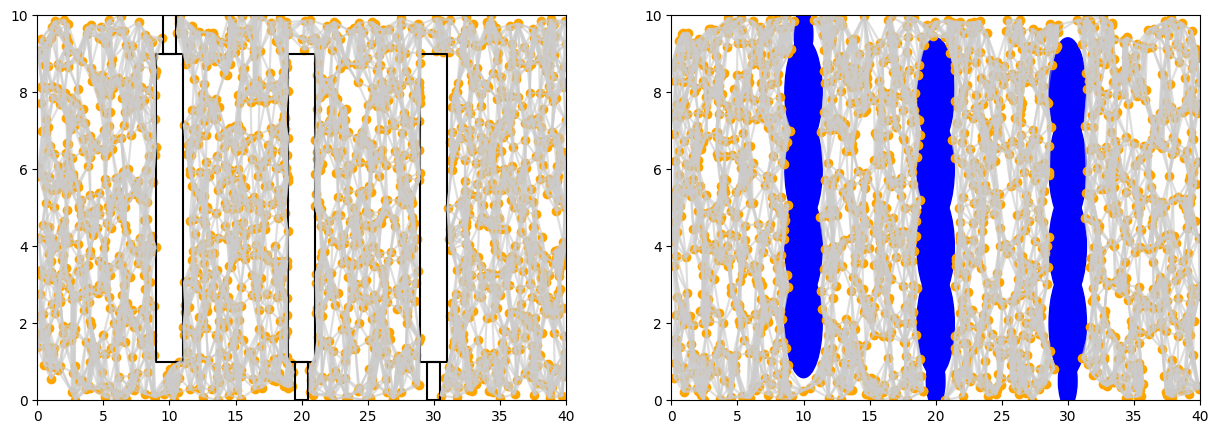

In [80]:
plt.rcParams['figure.figsize'] = [15, 5]
fig, ax = plt.subplots(1, 2)

base_env.draw_environment(ax[0])
base_env_prm.draw(ax[0])

approx_env.draw_environment(ax[1])
approx_env_prm.draw(ax[1])
plt.show()

# Search Graphs for Paths

In [81]:
base_env_prm_path = base_env_prm.search(start, target)
approx_env_prm_path = approx_env_prm.search(start, target)

# Visualize Base Environment and Approximation Environment PRM Graphs with Paths

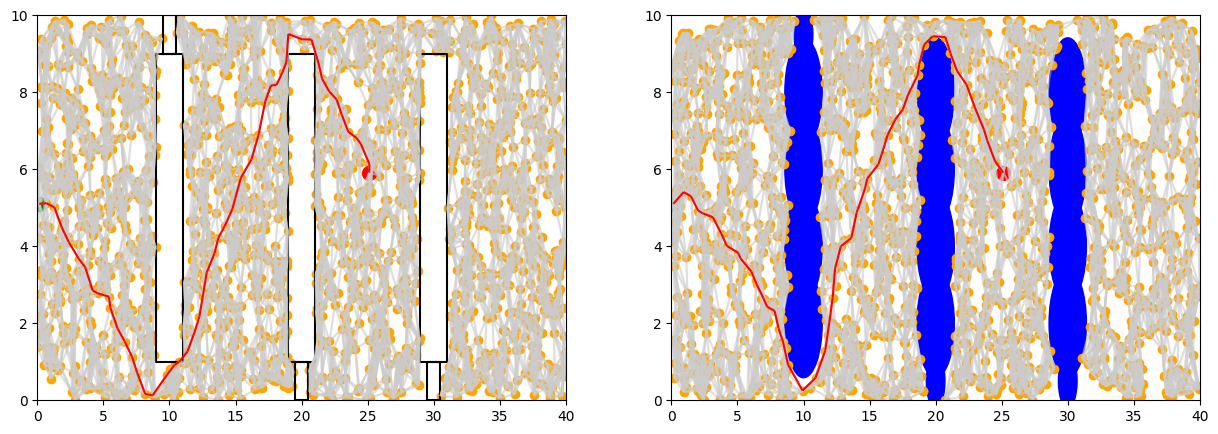

In [83]:
fig, ax = plt.subplots(1, 2)

base_env.draw_environment(ax[0])
base_env_prm.draw(ax[0], path=base_env_prm_path, show_task=True)

approx_env.draw_environment(ax[1])
approx_env_prm.draw(ax[1], path=approx_env_prm_path, show_task=True)
plt.show()